# Linear Regression

Shape: (11914, 16)

Missing values:
engine_fuel_type       3
engine_hp             69
engine_cylinders      30
number_of_doors        6
market_category     3742
dtype: int64


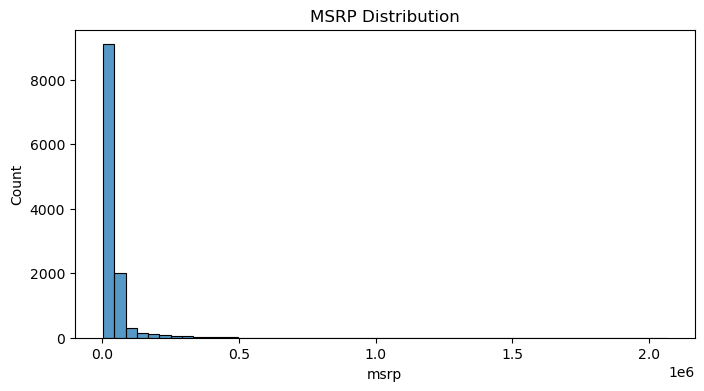

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv"

df = pd.read_csv(data)

# Clean column names and string values
df.columns = df.columns.str.lower().str.replace(" ", "_")

strings = df.select_dtypes(include=["object"]).columns

for column in strings:
    df[column] = df[column].str.lower().str.replace(" ", "_")

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

plt.figure(figsize=(8, 4))
sns.histplot(df['msrp'], bins=50)
plt.title("MSRP Distribution")
plt.show()

# Target transformation: log(1 + y)
y = np.log1p(df["msrp"])

# train, validation, test and log transformed

In [2]:
np.random.seed(2)

idx = np.arange(len(df))
np.random.shuffle(idx)

df_shuffled = df.iloc[idx].reset_index(drop=True)

n = len(df_shuffled)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train + n_val].copy()
df_test = df_shuffled.iloc[n_train + n_val:].copy()

# important: ekhane y er value gula kintu numpy array te convert kora and log trainsformed kora.
y_train = np.log1p(df_train["msrp"].values)
y_val = np.log1p(df_val["msrp"].values)
y_test = np.log1p(df_test["msrp"].values)

print("train:", len(df_train), "validation:", len(df_val), "test:", len(df_test))

train: 7150 validation: 2382 test: 2382


# preparing feature matrix(x) from df_train and df_val

In [3]:
# feature matrix e jei numerical column and categorical column niye kaj korbo tader list nilam
# ei list e column er just nam ase, kono value nai. value thakle oita df hoye jaito.
numerical_columns = [
    "engine_hp",
    "engine_cylinders",
    "highway_mpg",
    "city_mpg",
    "popularity"
]

# eta categorical column er list.
categorical_columns = [
    "make",
    "engine_fuel_type",
    "transmission_type",
    "driven_wheels",
    "market_category",
    "vehicle_size",
    "vehicle_style"
]


# ekhon categorical column er list theke protita value or column er nam niye df_train theke oi column er first 5 ta features niye ekta dictionary banabo. and ei dictionary te create_feature_matrix e pass korbo. jodi selected feature na niye shob feature nitam then amar dictionary bananor dorkar porto na.
categories = {}

for single_cat_column in categorical_columns:
    categories[single_cat_column] = df_train[single_cat_column].value_counts().head().index.to_list()

'''
1. dictionary te jevabe value set kore: 

    student = {}
    student["name"] = "Jihad"
    student["age"] = 25

2. categories dictionary er moddhe value jevabe ase:

    {
        "make": ["Toyota", "BMW", "Honda", "Chevrolet", "Ford"],
        "vehicle_size": ["Compact", "Midsize", "Large", "Small SUV", "Midsize SUV"],
    }
'''
pass

In [4]:
def create_feature_matrix(df, n_columns=numerical_columns, categories=categories):
    df = df.copy()
    features = n_columns.copy() # ei features list ta important. karon ei list e apatoto only numerical columns ase. but jotogula categorical column ase, oigulare numerical e convert kore ei features e rakha hobe.

    # ekhane simple ekta feature engineering kora hoise. and df and features e age name e new ekta column add korlam.
    df["age"] = 2017 - df["year"]
    features.append("age")

    # now ei part tuku only oi column gular jonne jader value nummerical but actually they are categorical.
    for door in [2, 3, 4]:
        feature = f"num_doors_{door}" # ei line e just column er nam create hoitese. jemon: num_doors_2
        df[feature] = (df["number_of_doors"] == door).astype(int) # uporer line e feature e column nam ase. oi nam diye df e ami ekta pandas series add korlam jekhane only 0 and 1 ase. eta one kind of simple one hot encoding.
        features.append(feature) # features list taw update kore dilam. 

    # ei part e categorical column niye kaj. categorical column ke numerical column e convert korbo.
    for column, values in categories.items(): # ekhane categories ekta dictionary. etar key ke column e rakhlam and value ke values e rakhlam. jemon: column = make, values = ["Toyota", "BMW", "Honda", "Chevrolet", "Ford"]
        for value in values:
            feature = f"{column}__{value}" # ei line e column er nam create hoitese. jemon: make__Toyota
            df[feature] = (df[column] == value).astype(int)
            features.append(feature)

    return df[features].fillna(0).values.astype(float) # now jei df_train receive korsilam oita done. oita return kore dibo. but important ekhane kintu ami dataframe return kortesi na. .values diye ami numpy array return kortesi. 

'''
so ei function e ki ki kora hoise:
    1. df_train or df_validation receive kora hoise.
    2. simple feature engineering kora hoise.
    3. categorical column ke numerical column e convert kora hoise.
    4. and finally NaN value ke 0 diye fill kore datframe ke numpy te convert kore numpy array return kora hoise.
'''


pass

In [5]:
x_train = create_feature_matrix(df_train, numerical_columns, categories)
x_val = create_feature_matrix(df_val, numerical_columns, categories)

In [6]:
x_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [285.,   6.,  22., ...,   0.,   0.,   0.],
       [563.,  12.,  21., ...,   0.,   0.,   0.],
       [200.,   4.,  31., ...,   0.,   0.,   0.]], shape=(7150, 41))

# finding (i) w0,w (ii) y_pred (iii) rmse

In [7]:
'''
w0(bias) and w(weights) dui vabe ber kora jay:
    1. without regularization
    2. with regularization
''' 
"""
1. প্রথমে X_train ও y_train দিয়ে model train করে w0 এবং w বের করা হয়।
2. তারপর X_val দিয়ে prediction (y_pred) করা হয় এবং y_val-এর সাথে compare করে RMSE বের করা হয়।
3. বিভিন্ন r value-এর জন্য এই process repeat করে সবচেয়ে ভালো r নির্বাচন করা হয়।
4. Best r পাওয়ার পর X_train + X_val এবং y_train + y_val একসাথে করে final model আবার train করা হয়।
5. এরপর X_test দিয়ে final prediction করা হয় এবং y_test-এর সাথে compare করে Final Test RMSE বের করা হয়।
"""


pass

### finding weights without regularization

In [8]:
# ei function ta important. karon linear regression e model fit mane ei function kei bojhay. ei function theke jei w0 and w ber hobe oigula linear regression er equation e boshaya target value predict kora hoy. so model fit mane ei function kei bujhay. 
def find_weights(x, y):
    ones = np.ones(x.shape[0])
    X = np.column_stack([ones, x])

    XTX = X.T.dot(X)
    XTy = X.T.dot(y)

    w = np.linalg.inv(XTX).dot(XTy)

    return w[0], w[1:]


w0, w = find_weights(x_train, y_train)

print("w0:", w0)
print("w:", w)

w0: -5.655044918146379e+16
w: [-1.71816484e-01  1.14938867e+01 -1.80390770e-01  1.82350742e+01
  1.66186304e-03  2.11574495e+00  3.55174563e+03  3.51152588e+03
  3.50025521e+03 -1.21953461e+01 -2.53160465e+01  8.35048392e+01
 -4.22133711e+01  1.36709872e+01 -3.70001145e+02 -3.11375433e+02
 -3.30998678e+02 -2.44103581e+02 -8.63750518e+02  5.80916092e+16
  5.80916092e+16  5.80916092e+16  5.80916092e+16  5.80916092e+16
 -1.54115997e+15 -1.54115997e+15 -1.54115997e+15 -1.54115997e+15
  3.71282384e+01  1.47073671e+01  1.17788783e+01  5.33017226e+01
  4.61788916e+01 -4.48000000e+02 -4.32000000e+02 -4.88000000e+02
 -4.85492239e-02  5.44797374e-02  1.78241160e-01  3.41906701e-01
 -1.64412078e-01]


In [9]:
y_pred = w0 + x_val.dot(w)

rmse = np.sqrt(np.mean((y_val - y_pred) ** 2))
rmse

np.float64(181.66659500138746)

### finding weights with regularization

In [10]:
def find_weights_regularization(x, y, r):
    ones = np.ones(x.shape[0])
    X = np.column_stack([ones, x])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [13]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:  
    w0, w = find_weights_regularization(x_train, y_train, r)

    y_pred = w0 + x_val.dot(w)
    rmse = np.sqrt(np.mean((y_val - y_pred) ** 2))
    
    # print(r, w0, score)
    print(f"r={r:.5f}, w0={w0:.5f}, RMSE={rmse:.5f}")

r=0.00000, w0=-56550449181465104.00000, RMSE=134.17876
r=0.00001, w0=-0.19772, RMSE=0.45652
r=0.00010, w0=6.31184, RMSE=0.45652
r=0.00100, w0=6.28511, RMSE=0.45652
r=0.10000, w0=6.19121, RMSE=0.45657
r=1.00000, w0=5.63490, RMSE=0.45722
r=10.00000, w0=4.28398, RMSE=0.47015


In [ ]:
# uporer loop theke 0.001, 0.0001, 0.00001 ei 3 ta r er value er jonne rmse shobcheye kom ashche. ei 3 ta theke jekono ekta(0.001) nibo. niye find_weights_regularization function call korbo. 

# but ebar x_train and y_train diye call korbo na. x_train_full(x_train + x_val) and y_train_full(y_train + y_val) diye call korbo. 

# next